In [1]:
import os
import gymnasium as gym
from stable_baselines3.ppo import PPO
from stable_baselines3.ppo.policies import MlpPolicy as MLP_PPO
from netsim.netSimPy import *
from netsim.gym_basic.envs import S_RMSA_ENV_BEST
from netsim.netSimPy.common.plot_utils import smooth
from stable_baselines3.common.monitor import Monitor
import numpy as np
import tensorflow as tf
import logging
from IPython.display import clear_output

logging.getLogger("tensorflow").setLevel(logging.FATAL)
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import sync_envs_normalization

tf.__version__

/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'2.16.2'

In [2]:
from typing import Optional


class MyBestCallback(EvalCallback):
    def __init__(
        self,
        eval_env: S_RMSA_ENV_BEST,
        callback_on_new_best=None,
        callback_after_eval=None,
        n_eval_episodes: int = 5,
        eval_freq: int = 10000,
        log_path: Optional[str] = None,
        best_model_save_path: Optional[str] = None,
        deterministic: bool = True,
        render: bool = False,
        verbose: int = 1,
        warn: bool = True,
        smoothing=0.992,
    ):
        super().__init__(
            eval_env,
            callback_on_new_best,
            callback_after_eval,
            n_eval_episodes,
            eval_freq,
            log_path,
            best_model_save_path,
            deterministic,
            render,
            verbose,
            warn,
        )
        self.eval_env = eval_env
        self.best_reward_at = 0
        self.best_mean_reward_at = 0
        self.last = 0
        self.best_smooth = 0
        self.smoothing = smoothing
        self.best_mean_reward = -np.inf
        self.num_acc = 0

    def _on_step(self) -> bool:
        continue_training = True

        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            # Sync training and eval env if there is VecNormalize
            if self.model.get_vec_normalize_env() is not None:
                try:
                    sync_envs_normalization(self.training_env, self.eval_env)
                except AttributeError as e:
                    raise AssertionError(
                        "Training and eval env are not wrapped the same way, "
                        "see https://stable-baselines3.readthedocs.io/en/master/guide/callbacks.html#evalcallback "
                        "and warning above."
                    ) from e

            # Reset success rate buffer
            self._is_success_buffer = []
            # self.eval_env.reset(hard_reset=True)
            episode_rewards, episode_lengths = evaluate_policy(
                self.model,
                self.eval_env,
                n_eval_episodes=self.n_eval_episodes,
                render=self.render,
                deterministic=self.deterministic,
                return_episode_rewards=True,
                warn=self.warn,
                callback=self._log_success_callback,
            )

            if self.log_path is not None:
                self.evaluations_timesteps.append(self.num_timesteps)
                self.evaluations_results.append(episode_rewards)
                self.evaluations_length.append(episode_lengths)

                kwargs = {}
                # Save success log if present
                if len(self._is_success_buffer) > 0:
                    self.evaluations_successes.append(self._is_success_buffer)
                    kwargs = dict(successes=self.evaluations_successes)

                np.savez(
                    self.log_path,
                    timesteps=self.evaluations_timesteps,
                    results=self.evaluations_results,
                    ep_lengths=self.evaluations_length,
                    **kwargs,
                )

            mean_reward, std_reward = np.mean(episode_rewards), np.std(episode_rewards)
            mean_ep_length, std_ep_length = np.mean(episode_lengths), np.std(
                episode_lengths
            )
            self.last_mean_reward = mean_reward

            smoothed, self.last = smooth(
                self.last, mean_reward, self.smoothing, self.num_acc
            )
            self.num_acc += 1

            if self.verbose >= 1:
                print(
                    f"Eval num_timesteps={self.num_timesteps}, "
                    f"episode_reward={mean_reward:.2f} +/- {std_reward:.2f}"
                )
            # Add to current Logger
            self.logger.record("eval/mean_reward", float(mean_reward))
            self.logger.record("eval/mean_ep_length", mean_ep_length)

            if len(self._is_success_buffer) > 0:
                success_rate = np.mean(self._is_success_buffer)
                if self.verbose >= 1:
                    print(f"Success rate: {100 * success_rate:.2f}%")
                self.logger.record("eval/success_rate", success_rate)

            # Dump log so the evaluation results are printed with the correct timestep
            self.logger.record(
                "time/total_timesteps", self.num_timesteps, exclude="tensorboard"
            )
            self.logger.dump(self.num_timesteps)

            if mean_reward >= self.best_mean_reward:
                self.model.save(
                    os.path.join(self.best_model_save_path, "mean_reward_model")
                )
                self.best_mean_reward_at = self.num_timesteps
                self.best_mean_reward = float(mean_reward)

            if smoothed >= self.best_smooth:
                self.best_reward_at = self.num_timesteps
                if self.best_model_save_path is not None:
                    self.model.save(
                        os.path.join(self.best_model_save_path, "smooth_model")
                    )
                self.best_smooth = smoothed
                # Trigger callback on new best model, if needed
                if self.callback_on_new_best is not None:
                    continue_training = self.callback_on_new_best.on_step()
            print(
                f"Best smoothed reward: {self.best_smooth:.2f} at timestep No. {self.best_reward_at}"
            )
            print(
                f"Best episode reward: {self.best_mean_reward:.2f} at timestep No. {self.best_mean_reward_at}"
            )
            clear_output(wait=True)
            # Trigger callback after every evaluation, if needed
            if self.callback is not None:
                continue_training = continue_training and self._on_event()

        return continue_training

### Training:


In [3]:
# FILES AND DIRECTORIES:
__file__ = "S-RMSA.ipynb"
absolutepath = os.path.abspath(__file__)
file_name = os.path.basename(os.path.abspath(__file__)).split(".")[0]
networkPaths = "/Users/jbcedeno/Documents/projcts/multiband-gymnasium/networks/arpanet"
log_dir = f"./tmp/{file_name}/"
os.makedirs(log_dir, exist_ok=True)
tensorboard_log = f"./tb/{file_name}/arpanet/"

# SIMULATION PARAMS:
TOTAL_TIMESTEPS = int(4e6)
# TOTAL_TIMESTEPS = int(8e6)
EPISODE_LENGTH = 1000
N_EVALUATION_EPISODES = 5
EVAL_FREQ = N_EVALUATION_EPISODES * EPISODE_LENGTH
N_BLOCKS = 1
N_PATHS = 5
M_LAMBDA = 25000  # 250 Erlangs

# Building the network simulator:
network = Network(
    networkFileName=networkPaths + "/network.json",
    pathsFileName=networkPaths + "/routes.json",
    bitrateFilename=networkPaths + "/bitrates_c_bands.json",
)
generator = EventsGenerator(mLambda=M_LAMBDA)
sim_args = dict(eventsGenerator=generator, network=network)
simulator = NetworkSimulator(**sim_args)


# Building the environment:
env_args = dict(
    simulator=simulator,
    episode_length=EPISODE_LENGTH,
    j=N_BLOCKS,
    n_paths=N_PATHS,
)

env: S_RMSA_ENV_BEST = Monitor(gym.make("S_RMSA_ENV_BEST-v0", **env_args), log_dir)

# MODEL HYPERPARAMETERS:
mArgs = dict(
    learning_rate=0.00005,
    clip_range=0.05,
    n_steps=2048,
    gamma=0.9,
    gae_lambda=0.92,
    ent_coef=0.002,
    # # n_epochs=23,
    # batch_size = 16,
    # # ent_coef= 0.0015,
    n_epochs=16,
)
model = PPO(MLP_PPO, env, verbose=0, seed=3, tensorboard_log=tensorboard_log, **mArgs)


# callback = CustomCallback(env, eval_freq=EVAL_FREQ, n_eval_episodes=N_EVALUATION_EPISODES, verbose=0, log_path=log_dir)
eval_env: S_RMSA_ENV_BEST = Monitor(
    gym.make("S_RMSA_ENV_BEST-v0", **env_args), log_dir + "eval_env"
)
# best_model_save_path = os.path.join(log_dir, "best_model")
callback = MyBestCallback(
    eval_env,
    n_eval_episodes=N_EVALUATION_EPISODES,
    eval_freq=EVAL_FREQ,
    log_path=log_dir,
    best_model_save_path=log_dir,
    verbose=1,
)
train_model = model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback)
# 997.2

Eval num_timesteps=4000000, episode_reward=813.80 +/- 33.30
Best smoothed reward: 813.85 at timestep No. 3850000
Best episode reward: 850.40 at timestep No. 3435000


### Funciones útiles


In [4]:
import uuid


def pairwise(iterable):
    return list(zip(iterable, iterable[1:]))


def set_link_fail(env, linkID: str = f"{0}-{2}"):
    env.reset(options={"hard_reset": True})
    network = env.unwrapped.simulator.network
    con = network.generateConnectionRequest(uuid.uuid4())
    con.src = int(linkID.split("-")[0])
    con.dst = int(linkID.split("-")[1])
    lengths = network.lengths
    linksOfPath = [network.links[linkID]]
    bestModulation = con.bitRate.getBestModulationByBand(
        linksOfPath, lengths[con.src, con.dst][0], "C"
    )

    for link in linksOfPath:
        con.addLinkInfo(
            link.id,
            fromSlot=0,
            toSlot=344,
            band="C",
            modulation=bestModulation,
        )
    env.unwrapped.simulator.network.allocate(con)


def evaluate_for(model, env, n_timesteps, linkID_fail=None):
    timesteps_count = 0
    total_blocked = 0
    state = None
    done = False
    observation = env.reset()[0]
    if linkID_fail:
        set_link_fail(env, linkID_fail)

    while timesteps_count < n_timesteps:
        # if timesteps_count == 5:
        #     print(env.unwrapped.simulator.network.links["3-4"].getSlots("C"))
        act, state = model.predict(
            observation,
            state=state,
            episode_start=done,
            deterministic=True,
        )
        observation, reward, done, truncated, info = env.step(act)
        if reward == -1:
            total_blocked += 1
        if done:
            env.reset()
        timesteps_count += 1
    print("total_blocked", total_blocked)
    return f"{total_blocked/n_timesteps:.6f}"


#

### Comparación de BP entre agente, protected SAP, y método 1 + 1


In [ ]:
# Agente:

traffics = [
    5000,
    6000,
    7000,
    8000,
    9000,
    10000,
    11000,
]
tsteps = 100000
for t in traffics:
    print("agente -- ", t)
    env: S_RMSA_ENV_BEST = gym.make("S_RMSA_ENV_BEST-v0", **env_args)
    env.reset(options={"lambda": t, "hard_reset": True})
    model2 = PPO.load(f"./tmp/{file_name}/smooth_model.zip")
    bp = evaluate_for(model2, env, tsteps)
    print(bp)

# [0.000320, 0.000820, 0.001560, 0.002760, 0.004730, 0.007310, 0.010490]

agente --  5000
total_blocked 32
0.000320
agente --  6000
total_blocked 82
0.000820
agente --  7000
total_blocked 156
0.001560
agente --  8000
total_blocked 276
0.002760
agente --  9000
total_blocked 473
0.004730
agente --  10000
total_blocked 731
0.007310
agente --  11000
total_blocked 1049
0.010490


In [ ]:
# Protected SAP:

from netsim.netSimPy.common.allocators import protected_sap_ff
from netsim.netSimPy.common.evaluators import SimpleEvaluator


for t in traffics:
    print("protected_sap_ff -- ", t)
    network = Network(
        networkFileName=networkPaths + "/network.json",
        pathsFileName=networkPaths + "/routes.json",
        bitrateFilename=networkPaths + "/bitrates_c_bands.json",
    )
    generator = EventsGenerator(mLambda=t)

    sim_args = dict(
        eventsGenerator=generator,
        network=network,
        allocator=protected_sap_ff(5, ["C"]),
    )

    simulator = NetworkSimulator(**sim_args)
    simulator.run(tsteps, SimpleEvaluator(with_protection=True))

    # [0.00038, 0.00098, 0.00204, 0.00365, 0.00638, 0.00954, 0.0134]

    #

protected_sap_ff --  5000
Total blocked events: 38 for a BP=0.00038
protected_sap_ff --  6000
Total blocked events: 98 for a BP=0.00098
protected_sap_ff --  7000
Total blocked events: 204 for a BP=0.00204
protected_sap_ff --  8000
Total blocked events: 365 for a BP=0.00365
protected_sap_ff --  9000
Total blocked events: 638 for a BP=0.00638
protected_sap_ff --  10000
Total blocked events: 954 for a BP=0.00954
protected_sap_ff --  11000
Total blocked events: 1340 for a BP=0.0134


In [ ]:
# Método 1+1:
from netsim.netSimPy.common.allocators import one_plus_one
from netsim.netSimPy.common.evaluators import SimpleEvaluator


for t in traffics:
    print("(1+1) -- ", t)
    network = Network(
        networkFileName=networkPaths + "/network.json",
        pathsFileName=networkPaths + "/routes.json",
        bitrateFilename=networkPaths + "/bitrates_c_bands.json",
    )
    generator = EventsGenerator(mLambda=t)

    sim_args = dict(
        eventsGenerator=generator,
        network=network,
        allocator=one_plus_one(),
    )

    simulator = NetworkSimulator(**sim_args)
    simulator.run(tsteps, SimpleEvaluator(with_protection=True))

    # [0.00174, 0.00421, 0.00764, 0.01166, 0.01561, 0.01989, 0.02473]

    #

(1+1) --  5000
Total blocked events: 174 for a BP=0.00174
(1+1) --  6000
Total blocked events: 421 for a BP=0.00421
(1+1) --  7000
Total blocked events: 764 for a BP=0.00764
(1+1) --  8000
Total blocked events: 1166 for a BP=0.01166
(1+1) --  9000
Total blocked events: 1561 for a BP=0.01561
(1+1) --  10000
Total blocked events: 1989 for a BP=0.01989
(1+1) --  11000
Total blocked events: 2473 for a BP=0.02473


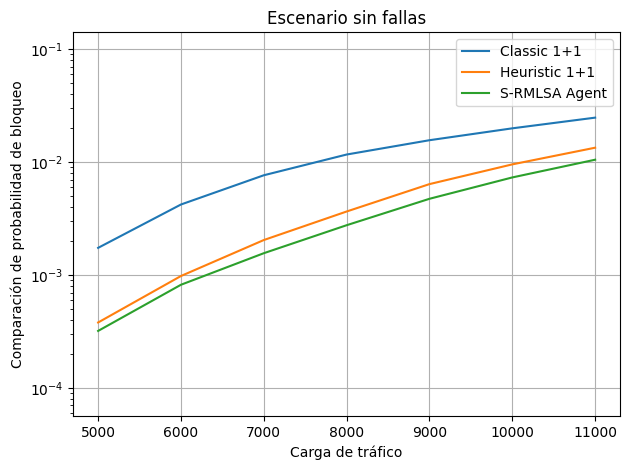

In [41]:
import matplotlib.pyplot as plt

bp_agent = [0.000320, 0.000820, 0.001560, 0.002760, 0.004730, 0.007310, 0.010490]
best_1_1 = [0.00038, 0.00098, 0.00204, 0.00365, 0.00638, 0.00954, 0.0134]
classic_1_1 = [0.00174, 0.00421, 0.00764, 0.01166, 0.01561, 0.01989, 0.02473]

plt.plot(traffics, classic_1_1, label="Classic 1+1")
plt.plot(traffics, best_1_1, label="Heuristic 1+1")
plt.plot(traffics, bp_agent, label="S-RMLSA Agent")
plt.margins(y=0.4)
plt.semilogy()
plt.xlabel("Carga de tráfico")
plt.ylabel(f"Comparación de probabilidad de bloqueo")
plt.title("Escenario sin fallas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Simulando falla de enlace 3-4


In [ ]:
for t in traffics:
    env.reset(options={"lambda": t})
    model2 = PPO.load(f"./tmp/{file_name}/smooth_model.zip")
    print(evaluate_for(model2, env, tsteps, "3-4"))

# [0.000210, 0.000510, 0.001380, 0.002470, 0.004350, 0.007010, 0.010220]

#

total_blocked 21
0.000210
total_blocked 51
0.000510
total_blocked 138
0.001380
total_blocked 247
0.002470
total_blocked 435
0.004350
total_blocked 701
0.007010
total_blocked 1022
0.010220


In [ ]:
def set_link_sim_failure(network, linkID: str):
    con = network.generateConnectionRequest(uuid.uuid4())
    con.src = int(linkID.split("-")[0])
    con.dst = int(linkID.split("-")[1])
    lengths = network.lengths
    linksOfPath = [network.links[linkID]]
    bestModulation = con.bitRate.getBestModulationByBand(
        linksOfPath, lengths[con.src, con.dst][0], "C"
    )

    for link in linksOfPath:
        con.addLinkInfo(
            link.id,
            fromSlot=0,
            toSlot=344,
            band="C",
            modulation=bestModulation,
        )
    network.allocate(con)


for t in traffics:
    print("(1+1) -- ", t)
    network = Network(
        networkFileName=networkPaths + "/network.json",
        pathsFileName=networkPaths + "/routes.json",
        bitrateFilename=networkPaths + "/bitrates_c_bands.json",
    )
    generator = EventsGenerator(mLambda=t)

    sim_args = dict(
        eventsGenerator=generator,
        network=network,
        allocator=one_plus_one(),
    )

    simulator = NetworkSimulator(**sim_args)
    set_link_sim_failure(network, "3-4")
    simulator.run(tsteps, SimpleEvaluator(with_protection=True))

#  [0.00694, 0.00924, 0.01238, 0.01627, 0.02051, 0.02485, 0.02934]

#

(1+1) --  5000
Total blocked events: 694 for a BP=0.00694
(1+1) --  6000
Total blocked events: 924 for a BP=0.00924
(1+1) --  7000
Total blocked events: 1238 for a BP=0.01238
(1+1) --  8000
Total blocked events: 1627 for a BP=0.01627
(1+1) --  9000
Total blocked events: 2051 for a BP=0.02051
(1+1) --  10000
Total blocked events: 2485 for a BP=0.02485
(1+1) --  11000
Total blocked events: 2934 for a BP=0.02934


In [ ]:
for t in traffics:
    print("protected_sap_ff -- ", t)
    network = Network(
        networkFileName=networkPaths + "/network.json",
        pathsFileName=networkPaths + "/routes.json",
        bitrateFilename=networkPaths + "/bitrates_c_bands.json",
    )
    generator = EventsGenerator(mLambda=t)

    sim_args = dict(
        eventsGenerator=generator,
        network=network,
        allocator=protected_sap_ff(5, ["C"]),
    )

    simulator = NetworkSimulator(**sim_args)
    set_link_sim_failure(network, "3-4")
    simulator.run(tsteps, SimpleEvaluator(with_protection=True))

# [0.00032, 0.00087, 0.00195, 0.00353, 0.00601, 0.00917, 0.01268]

#

protected_sap_ff --  5000
Total blocked events: 32 for a BP=0.00032
protected_sap_ff --  6000
Total blocked events: 87 for a BP=0.00087
protected_sap_ff --  7000
Total blocked events: 195 for a BP=0.00195
protected_sap_ff --  8000
Total blocked events: 353 for a BP=0.00353
protected_sap_ff --  9000
Total blocked events: 601 for a BP=0.00601
protected_sap_ff --  10000
Total blocked events: 917 for a BP=0.00917
protected_sap_ff --  11000
Total blocked events: 1268 for a BP=0.01268


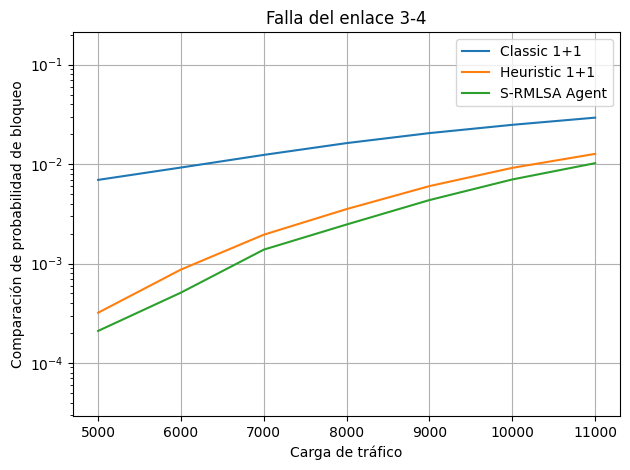

In [ ]:
bp_agent = [0.000210, 0.000510, 0.001380, 0.002470, 0.004350, 0.007010, 0.010220]
classic_1_1 = [0.00694, 0.00924, 0.01238, 0.01627, 0.02051, 0.02485, 0.02934]
best_1_1 = [0.00032, 0.00087, 0.00195, 0.00353, 0.00601, 0.00917, 0.01268]

plt.plot(traffics, classic_1_1, label="Classic 1+1")
plt.plot(traffics, best_1_1, label="Heuristic 1+1")
plt.plot(traffics, bp_agent, label="S-RMLSA Agent")
plt.margins(y=0.4)
plt.semilogy()
plt.xlabel("Carga de tráfico")
plt.ylabel(f"Comparación de probabilidad de bloqueo")
plt.title("Falla del enlace 3-4")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Simulando falla de enlace 7-9


In [ ]:
for t in traffics:
    env.reset(options={"lambda": t})
    model2 = PPO.load(f"./tmp/{file_name}/smooth_model.zip")
    print(evaluate_for(model2, env, tsteps, "7-9"))

# [0.000250, 0.000540, 0.001100, 0.002580, 0.004540, 0.007210, 0.010710]

#

total_blocked 25
0.000250
total_blocked 54
0.000540
total_blocked 110
0.001100
total_blocked 258
0.002580
total_blocked 454
0.004540
total_blocked 721
0.007210
total_blocked 1071
0.010710


In [ ]:
for t in traffics:
    print("(1+1) -- ", t)
    network = Network(
        networkFileName=networkPaths + "/network.json",
        pathsFileName=networkPaths + "/routes.json",
        bitrateFilename=networkPaths + "/bitrates_c_bands.json",
    )
    generator = EventsGenerator(mLambda=t)

    sim_args = dict(
        eventsGenerator=generator,
        network=network,
        allocator=one_plus_one(),
    )

    simulator = NetworkSimulator(**sim_args)
    set_link_sim_failure(network, "7-9")
    simulator.run(tsteps, SimpleEvaluator(with_protection=True))

# [0.01546, 0.01778, 0.02115, 0.02472, 0.02906, 0.03315, 0.03751]

#

(1+1) --  5000
Total blocked events: 1546 for a BP=0.01546
(1+1) --  6000
Total blocked events: 1778 for a BP=0.01778
(1+1) --  7000
Total blocked events: 2115 for a BP=0.02115
(1+1) --  8000
Total blocked events: 2472 for a BP=0.02472
(1+1) --  9000
Total blocked events: 2906 for a BP=0.02906
(1+1) --  10000
Total blocked events: 3315 for a BP=0.03315
(1+1) --  11000
Total blocked events: 3751 for a BP=0.03751


In [ ]:
for t in traffics:
    print("protected_sap_ff -- ", t)
    network = Network(
        networkFileName=networkPaths + "/network.json",
        pathsFileName=networkPaths + "/routes.json",
        bitrateFilename=networkPaths + "/bitrates_c_bands.json",
    )
    generator = EventsGenerator(mLambda=t)

    sim_args = dict(
        eventsGenerator=generator,
        network=network,
        allocator=protected_sap_ff(5, ["C"]),
    )

    simulator = NetworkSimulator(**sim_args)
    set_link_sim_failure(network, "7-9")
    simulator.run(tsteps, SimpleEvaluator(with_protection=True))

# [0.00039, 0.00099, 0.00194, 0.00384, 0.0061, 0.00927, 0.01336]

#

protected_sap_ff --  5000
Total blocked events: 39 for a BP=0.00039
protected_sap_ff --  6000
Total blocked events: 99 for a BP=0.00099
protected_sap_ff --  7000
Total blocked events: 194 for a BP=0.00194
protected_sap_ff --  8000
Total blocked events: 384 for a BP=0.00384
protected_sap_ff --  9000
Total blocked events: 610 for a BP=0.0061
protected_sap_ff --  10000
Total blocked events: 927 for a BP=0.00927
protected_sap_ff --  11000
Total blocked events: 1336 for a BP=0.01336


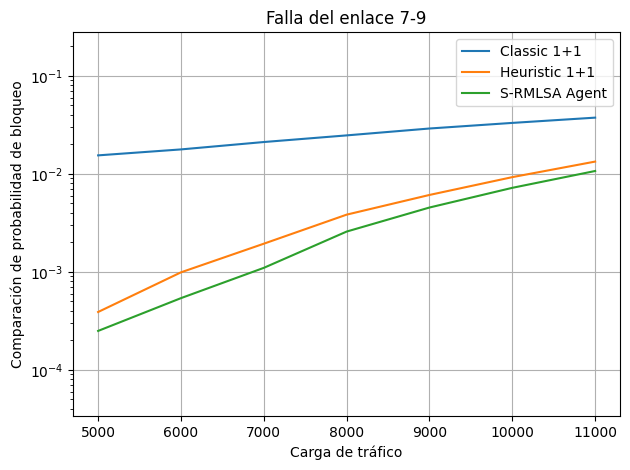

In [43]:
bp_agent = [0.000250, 0.000540, 0.001100, 0.002580, 0.004540, 0.007210, 0.010710]
classic_1_1 = [0.01546, 0.01778, 0.02115, 0.02472, 0.02906, 0.03315, 0.03751]
best_1_1 = [0.00039, 0.00099, 0.00194, 0.00384, 0.0061, 0.00927, 0.01336]

plt.plot(traffics, classic_1_1, label="Classic 1+1")
plt.plot(traffics, best_1_1, label="Heuristic 1+1")
plt.plot(traffics, bp_agent, label="S-RMLSA Agent")
plt.margins(y=0.4)
plt.semilogy()
plt.xlabel("Carga de tráfico")
plt.ylabel(f"Comparación de probabilidad de bloqueo")
plt.title("Falla del enlace 7-9")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()